<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Group_R_Data_exp%26Data_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#revanth kumar data preprocessing

In [22]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
#handle the forward slash
matching_paths = glob.glob('/content/drive/MyDrive/Hackathon_05*06/dataset_C_training.csv')

if len(matching_paths) > 0:
    file_path = matching_paths[0]
    # 2. Load the dataset
    df = pd.read_csv(file_path)
    print("Your dataset has loaded successfully.")
    print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
else:
    print("Could not find the file. Please double-check.")

Your dataset has loaded successfully.
Total Rows: 4756 | Total Columns: 31


In [29]:
# Isolate target variable
y = df['covid_vaccine'] #tgt variable

# Drop target and unique identifier to get our feature matrix
X = df.drop(columns=['respondent_id', 'covid_vaccine'])

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (4756, 29)
Target vector shape: (4756,)


In [30]:
# Identify text/categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Identify numerical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Found {len(categorical_cols)} text/categorical columns.")
print(f"Found {len(numeric_cols)} numerical columns.")

Found 10 text/categorical columns.
Found 19 numerical columns.


In [32]:
print("Missing values in numerical columns")
print(X[numeric_cols].isnull().sum()[X[numeric_cols].isnull().sum() > 0].sort_values(ascending=False))

print("Missing values in categorical columns")
print(X[categorical_cols].isnull().sum()[X[categorical_cols].isnull().sum() > 0].sort_values(ascending=False))

Missing values in numerical columns
health_insurance                1908
chronic_med_condition            169
child_under_6_months             135
health_worker                    132
opinion_covid_sick_from_vacc      90
household_adults                  39
household_children                39
covid_knowledge                   27
behavioral_avoidance              27
behavioral_touch_face             21
behavioral_outside_home           14
behavioral_antiviral_meds         14
covid_concern                     12
behavioral_large_gatherings       10
behavioral_wash_hands              9
behavioral_face_mask               2
dtype: int64
Missing values in categorical columns
employment_sector    2330
income_poverty        748
rent_or_own           329
employment_status     238
marital_status        231
education             228
dtype: int64


In [33]:


print("Preprocessing pipeline:")

#handling categorical variables
print("handle all the text variables")
# Fill missing strings with 'missing' value
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
X_cat_imputed = pd.DataFrame(cat_imputer.fit_transform(X[categorical_cols]), columns=categorical_cols)

#one_hot encoding from text to numerics 0,1
X_cat_encoded = pd.get_dummies(X_cat_imputed, drop_first=True)
print(f"Text categories converted. Categorical dimensions: {X_cat_encoded.shape}")


#KNN imputer
print("\n Imputing numerical gaps via KNN...")
#combining numerical features with encoded columns so knn can find similar rows
X_combined_for_knn = pd.concat([X[numeric_cols], X_cat_encoded], axis=1)
knn_imputer = KNNImputer(n_neighbors=5)
X_imputed_array = knn_imputer.fit_transform(X_combined_for_knn)

#rebuild_datadrame
X_imputed_df = pd.DataFrame(X_imputed_array, columns=X_combined_for_knn.columns)
print("knn imputation complete no missing values")


#feature scaling
print("\n normalise feature scales")
# Center features around 0 with a standard deviation of 1 (Vital for SVM and KNN models)
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_imputed_df)
X_final = pd.DataFrame(X_scaled_array, columns=X_imputed_df.columns)
print("feature scaling applied completely")


#attach the tgt variable again
X_final['covid_vaccine'] = y.values
print(f"Final clean dataset shape: {X_final.shape}")

Preprocessing pipeline:
handle all the text variables
Text categories converted. Categorical dimensions: (4756, 45)

 Imputing numerical gaps via KNN...
knn imputation complete no missing values

 normalise feature scales
feature scaling applied completely
Final clean dataset shape: (4756, 65)


In [34]:
# Save the clean dataset back to your shared folder path using the wildcard logic
export_path = matching_paths[0].replace('dataset_C_training.csv', 'super_dataset_C_train.csv')

X_final.to_csv(export_path, index=False)
print(f"File successfully saved to shared drive at:\n{export_path}")

File successfully saved to shared drive at:
/content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv


Starting EDA Plot Generation


/tmp/ipykernel_7811/3345170665.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='covid_vaccine', data=df, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_7811/3345170665.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Not Vaccinated (0)', 'Vaccinated (1)'])
/tmp/ipykernel_7811/3345170665.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.values, y=missing_data.index, ax=axes[0, 1], palette='flare_r')
/tmp/ipykernel_7811/3345170665.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

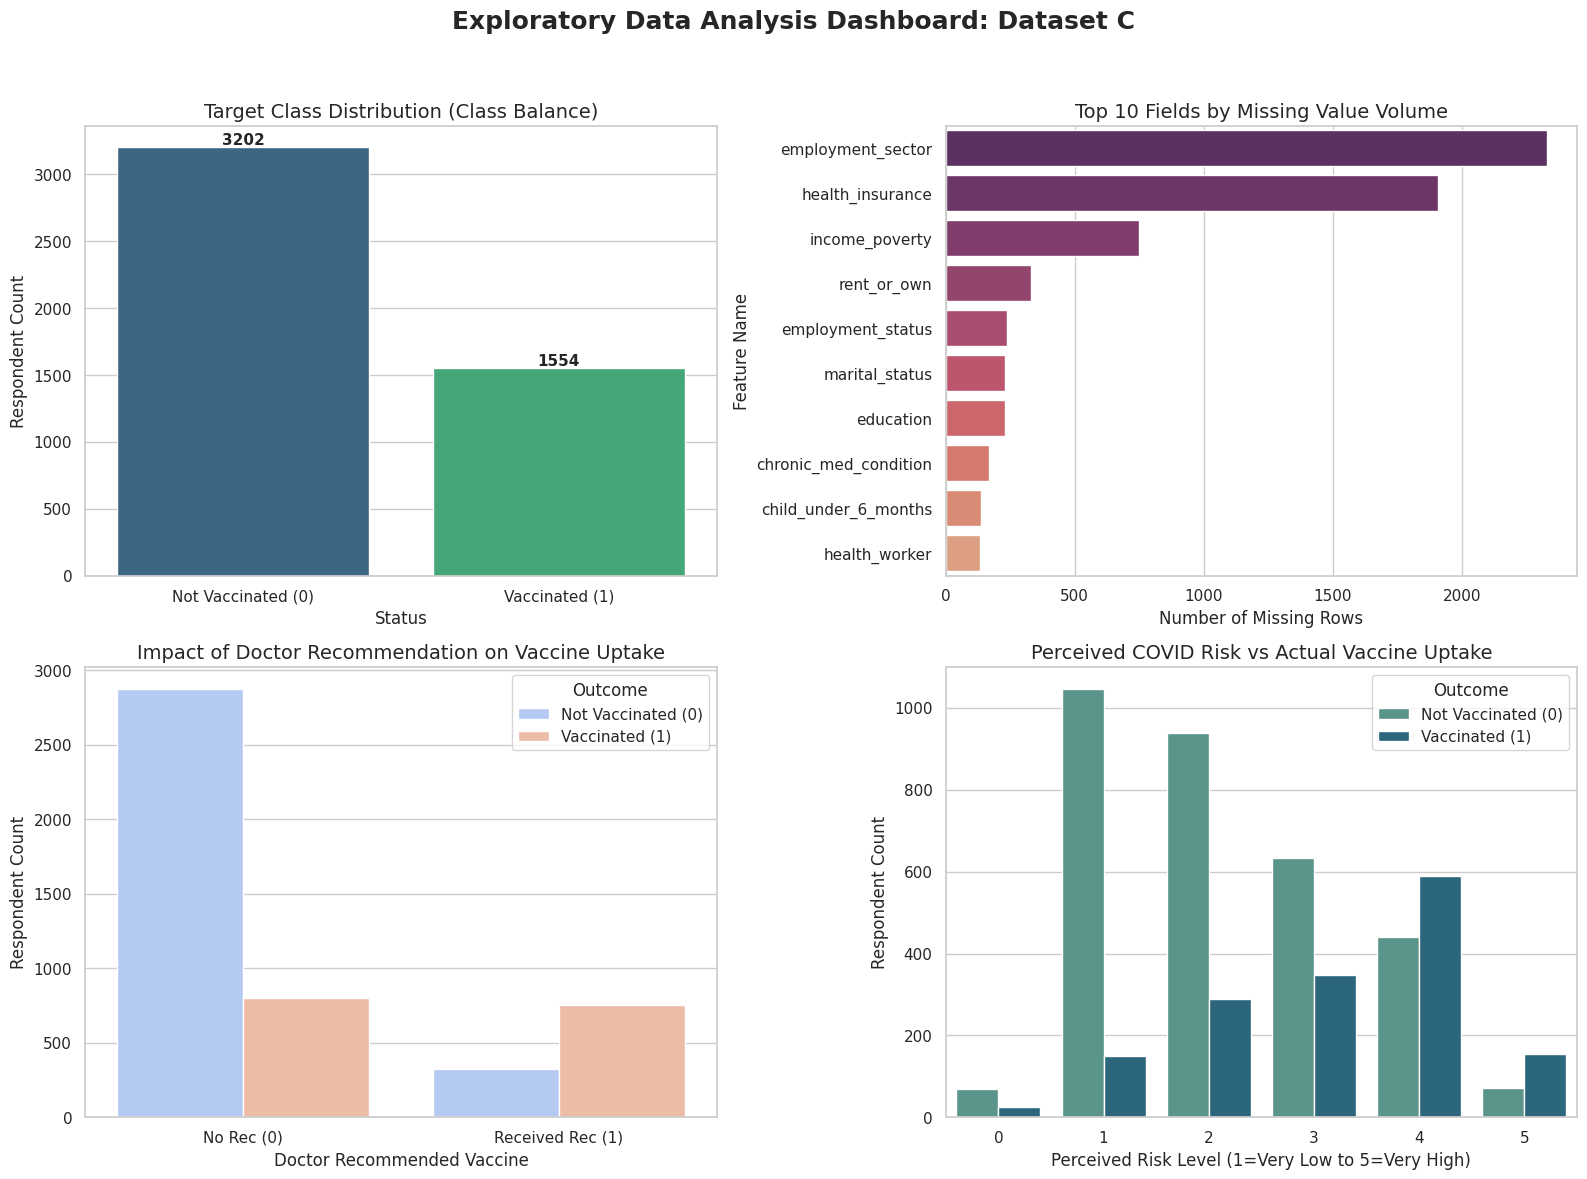


 Dashboard image saved successfully to shared folder:
/content/drive/MyDrive/Hackathon_05 06/eda_visualizations_dashboard.png


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Starting EDA Plot Generation")

#set standard styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

#2x2 for subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis Dashboard: Dataset C', fontsize=18, fontweight='bold', y=0.98)

#tgt variable balance
sns.countplot(x='covid_vaccine', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Target Class Distribution (Class Balance)')
axes[0, 0].set_xticklabels(['Not Vaccinated (0)', 'Vaccinated (1)'])
axes[0, 0].set_xlabel('Status')
axes[0, 0].set_ylabel('Respondent Count')

#count of labels
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')


#missing data
missing_counts = df.isnull().sum()
missing_data = missing_counts[missing_counts > 0].sort_values(ascending=False).head(10)
sns.barplot(x=missing_data.values, y=missing_data.index, ax=axes[0, 1], palette='flare_r')
axes[0, 1].set_title('Top 10 Fields by Missing Value Volume')
axes[0, 1].set_xlabel('Number of Missing Rows')
axes[0, 1].set_ylabel('Feature Name')


#doctor recommendation vs vaccine
if 'doctor_recc_covid' in df.columns:
    sns.countplot(x='doctor_recc_covid', hue='covid_vaccine', data=df, ax=axes[1, 0], palette='coolwarm')
    axes[1, 0].set_title('Impact of Doctor Recommendation on Vaccine Uptake')
    axes[1, 0].set_xticklabels(['No Rec (0)', 'Received Rec (1)'])
    axes[1, 0].set_xlabel('Doctor Recommended Vaccine')
    axes[1, 0].set_ylabel('Respondent Count')
    axes[1, 0].legend(['Not Vaccinated (0)', 'Vaccinated (1)'], title='Outcome')


#perceived risk vs vaccine uptake
if 'opinion_covid_risk' in df.columns:
    sns.countplot(x='opinion_covid_risk', hue='covid_vaccine', data=df, ax=axes[1, 1], palette='crest')
    axes[1, 1].set_title('Perceived COVID Risk vs Actual Vaccine Uptake')
    axes[1, 1].set_xlabel('Perceived Risk Level (1=Very Low to 5=Very High)')
    axes[1, 1].set_ylabel('Respondent Count')
    axes[1, 1].legend(['Not Vaccinated (0)', 'Vaccinated (1)'], title='Outcome')

plt.tight_layout(rect=[0, 0, 1, 0.95])

#save to shared folder
plot_output_path = matching_paths[0].replace('dataset_C_training.csv', 'eda_visualizations_dashboard.png')
plt.savefig(plot_output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Dashboard image saved successfully to shared folder:\n{plot_output_path}")

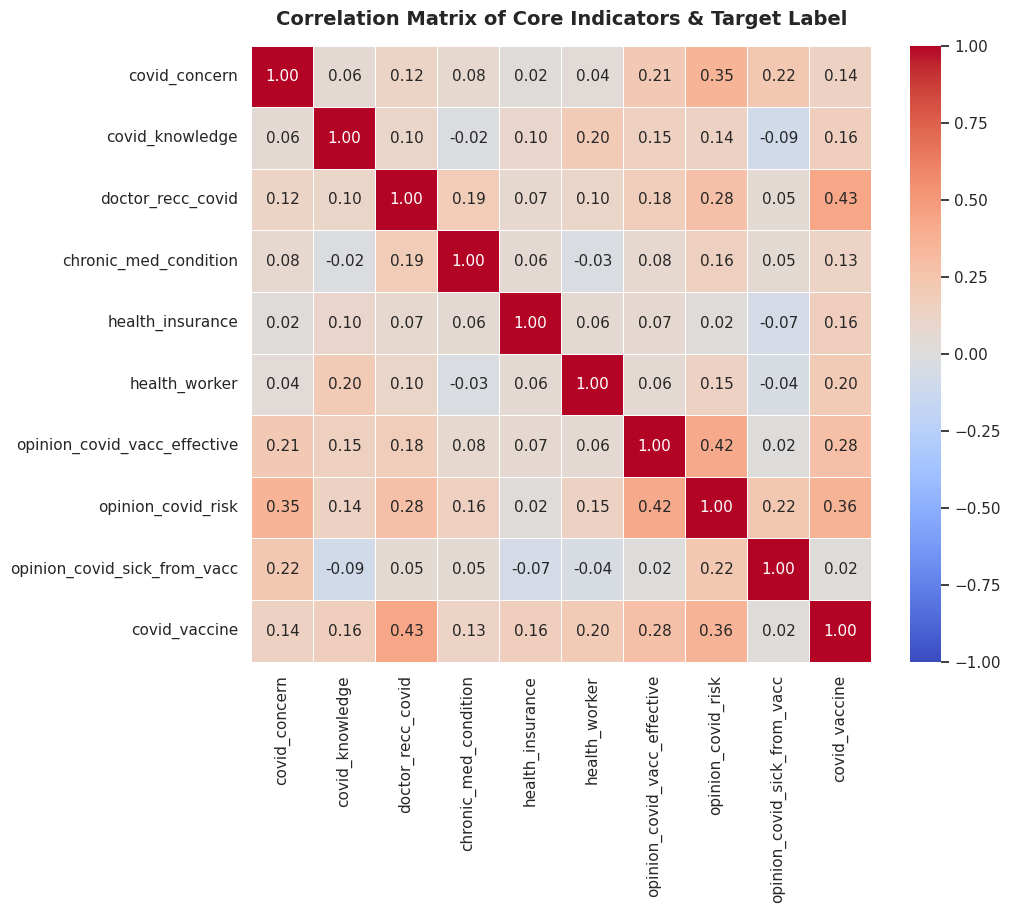

Correlation Heatmap image saved to shared folder:
/content/drive/MyDrive/Hackathon_05 06/eda_correlation_heatmap.png


In [36]:
#correlation heatmap
numerical_indicators = [
    'covid_concern', 'covid_knowledge', 'doctor_recc_covid',
    'chronic_med_condition', 'health_insurance', 'health_worker',
    'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc',
    'covid_vaccine'
]

#ensure they exists
valid_cols = [col for col in numerical_indicators if col in df.columns]
corr_matrix = df[valid_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Core Indicators & Target Label', fontsize=14, fontweight='bold', pad=15)

#save heatmap
heatmap_output_path = matching_paths[0].replace('dataset_C_training.csv', 'eda_correlation_heatmap.png')
plt.savefig(heatmap_output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation Heatmap image saved to shared folder:\n{heatmap_output_path}")